# Barrier Refinement

Once you have an initial estimate of the energy barrier (from path sampling, for example), you can refine it using energy-filtered A* search. The ratchet algorithm repeatedly searches for paths below a ceiling energy, lowering the ceiling each time a better path is found. This progressively tightens the upper bound on the minimum energy barrier.

This guide explains how the ratchet algorithm works and how to use it.

## Energy Ceiling Filtering

Unlike the minimum distance filter (which rejects structures where atoms are too close), an energy ceiling filter rejects structures whose energy exceeds a specified threshold. This directly constrains the barrier: if A* finds a path where all structures have energy below the ceiling, the path's barrier is guaranteed to be at most the ceiling value.

Energy filtering requires evaluating the energy of each candidate structure during the search, which is more expensive than geometric filtering. We use GRACE, a machine learning potential, to make this tractable. Each energy evaluation takes a few milliseconds, and we cache results to avoid redundant calculations.

## The Ratcheting Mechanism

The ratchet algorithm works as follows:

1. Start with an initial ceiling (from a previous path sampling run, or a rough estimate)
2. Run A* search with the energy ceiling filter
3. If a path is found, lower the ceiling to the path's barrier (or by a minimum step)
4. Repeat until the search fails to find a path

The ceiling only ever decreases, like a ratchet mechanism. Each successful search tightens our upper bound on the true minimum barrier.

When the search fails (no path below the current ceiling), it doesn't mean we've found the optimal barrier. The discretization might be too coarse to represent the true minimum-energy pathway. So the algorithm adapts: it refines the discretization parameters (smaller xi, larger delta) and tries again.

## A Simple Example

Let's refine the barrier between two zirconium structures. We'll start with a relatively high ceiling and let the ratchet find progressively lower-barrier paths.

In [1]:
from pymatgen.core import Structure, Lattice
from cnf import CNFConstructor, UnitCell

# HCP zirconium
a_hcp, c_hcp = 3.23, 5.15
lattice_hcp = Lattice.hexagonal(a_hcp, c_hcp)
zr_hcp = Structure(
    lattice_hcp,
    ["Zr", "Zr"],
    [[0, 0, 0], [1/3, 2/3, 0.5]]
)

# BCC-like zirconium (different structure)
a_bcc = 3.6
lattice_bcc = Lattice.tetragonal(a_bcc, a_bcc * 1.1)
zr_bcc = Structure(
    lattice_bcc,
    ["Zr", "Zr"],
    [[0, 0, 0], [0.5, 0.5, 0.5]]
)

print(f"HCP volume: {zr_hcp.volume:.2f} Ang^3")
print(f"BCC-like volume: {zr_bcc.volume:.2f} Ang^3")

# Create UnitCells
start_uc = UnitCell.from_pymatgen_structure(zr_hcp)
end_uc = UnitCell.from_pymatgen_structure(zr_bcc)

# Convert to CNF
xi = 1.5
delta = 30
constructor = CNFConstructor(xi=xi, delta=delta)

start_cnf = constructor.from_pymatgen_structure(zr_hcp).cnf
goal_cnf = constructor.from_pymatgen_structure(zr_bcc).cnf

print(f"\\nStart CNF (HCP): {start_cnf.coords[:7]}...")
print(f"Goal CNF (BCC):  {goal_cnf.coords[:7]}...")

HCP volume: 46.53 Ang^3
BCC-like volume: 51.32 Ang^3
\nStart CNF (HCP): (7, 7, 18, 25, 7, 25, 25)...
Goal CNF (BCC):  (8, 9, 10, 26, 17, 17, 19)...


In [2]:
from cnf.navigation.astar.iterative import ratchet
from cnf.calculation.grace import GraceCalculator

# Create energy calculator
calc = GraceCalculator()

# Compute endpoint energies to set initial ceiling
e_start = calc.calculate_energy(start_cnf)
e_end = calc.calculate_energy(goal_cnf)
max_endpoint = max(e_start, e_end)

# Set initial ceiling 200 meV/atom above the higher endpoint
n_atoms = len(start_cnf.elements)
initial_ceiling = max_endpoint + 0.200 * n_atoms

print(f"Start energy: {e_start:.4f} eV ({e_start/n_atoms:.4f} eV/atom)")
print(f"End energy: {e_end:.4f} eV ({e_end/n_atoms:.4f} eV/atom)")
print(f"Initial ceiling: {initial_ceiling:.4f} eV ({initial_ceiling/n_atoms:.4f} eV/atom)")

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.


Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License


2026-03-13 19:23:43.551026: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x16392cab0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:23:43.551038: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:23:43.662889: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


Start energy: -17.0654 eV (-8.5327 eV/atom)
End energy: -16.9389 eV (-8.4695 eV/atom)
Initial ceiling: -16.5389 eV (-8.2695 eV/atom)


2026-03-13 19:23:44.463343: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:23:44.467287: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


In [3]:
result = ratchet(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    initial_ceiling=initial_ceiling,
    energy_calc=calc,
    start_uc=start_uc,
    end_uc=end_uc,
    max_adaptations=2,
    max_iterations=2000,
    verbosity=1,
)


Starting ratchet refinement
  Max endpoint energy (discretized): -8.4695 eV/atom
  Max endpoint energy (original):    -8.4438 eV/atom
  Discretization shift: -25.7 meV/atom
  Initial ceiling: 200.0 meV/atom above endpoint
  Ceiling step: 2.0 meV/atom
  Max adaptations: 2
  xi_factor=0.8, delta_factor=1.2

Estimating initial max_iters...
  Estimating max_iters: attempt 1/5, trying 5000
  Path found in 29 iters -> using max_iters=43

Attempt 0 (ceiling=200.0/174.3 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=29, barrier=197.9/172.3 meV/atom disc/orig, iters=29
  Ceiling: 200.0/174.3 → 197.9/172.3 meV/atom disc/orig

Attempt 1 (ceiling=197.9/172.3 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=29, barrier=197.1/171.5 meV/atom disc/orig, iters=29
  Ceiling: 197.9/172.3 → 195.9/170.3 meV/atom disc/orig

Attempt 2 (ceiling=195.9/170.3 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=29, barrier=195.8/170.2 meV/atom disc/orig, iters=29
  Ceiling: 195.9/170.3 → 193.9/168.3 meV/atom disc/orig

Attempt 3 (ceiling=193.9/168.3 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=29, barrier=193.2/167.6 meV/atom disc/orig, iters=29
  Ceiling: 193.9/168.3 → 191.9/166.3 meV/atom disc/orig

Attempt 4 (ceiling=191.9/166.3 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


...

  PATH FOUND: len=29, barrier=9.6/-16.0 meV/atom disc/orig, iters=29
  Ceiling: 10.1/-15.6 → 8.1/-17.6 meV/atom disc/orig

Attempt 81 (ceiling=8.1/-17.6 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=29, barrier=7.9/-17.7 meV/atom disc/orig, iters=29
  Ceiling: 8.1/-17.6 → 6.1/-19.6 meV/atom disc/orig

Attempt 82 (ceiling=6.1/-19.6 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=30, barrier=5.6/-20.0 meV/atom disc/orig, iters=31
  Ceiling: 6.1/-19.6 → 4.1/-21.6 meV/atom disc/orig

Attempt 83 (ceiling=4.1/-21.6 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=30, barrier=3.8/-21.9 meV/atom disc/orig, iters=31
  Ceiling: 4.1/-21.6 → 2.1/-23.6 meV/atom disc/orig

Attempt 84 (ceiling=2.1/-23.6 meV/atom disc/orig, xi=1.50, delta=30, max_iters=43)
  Consecutive failures: 0, adaptations: 0/2


  PATH FOUND: len=32, barrier=0.6/-25.1 meV/atom disc/orig, iters=33
  Barrier (0.6 meV/atom) < ceiling step (2.0 meV/atom)
  Found optimal path - terminating ratchet.

Final result:
  Barrier: 0.6/-25.1 meV/atom disc/orig
  Path length: 32 steps
  Total attempts: 84
  Parameter adaptations: 0
  Energy cache size: 15319
  Total time: 82.4s


## Understanding the Output

The ratchet logs show each attempt with its ceiling (in meV/atom above the endpoint), whether a path was found, and how the ceiling changed. When consecutive failures occur, the algorithm adapts the discretization parameters.

The final result contains all paths found during refinement. The best path has the lowest barrier.

In [4]:
print(f"Total attempts: {len(result.results)}")
print(f"Paths found: {len(result.all_paths)}")

if result.best_path:
    best = result.best_path
    barrier_per_atom = (best.barrier / n_atoms - max_endpoint / n_atoms) * 1000
    print(f"Best barrier: {best.barrier:.4f} eV ({barrier_per_atom:.1f} meV/atom above endpoint)")
    print(f"Best path length: {len(best)} steps")

Total attempts: 85
Paths found: 85
Best barrier: -16.9378 eV (0.6 meV/atom above endpoint)
Best path length: 32 steps


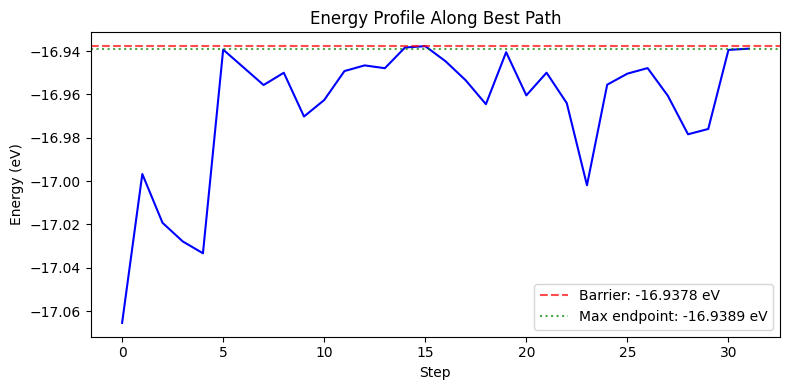

In [5]:
import matplotlib.pyplot as plt

if result.best_path:
    best = result.best_path
    
    # Plot energy profile
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(best.energies, 'b-', linewidth=1.5)
    ax.axhline(best.barrier, color='r', linestyle='--', alpha=0.7, 
               label=f'Barrier: {best.barrier:.4f} eV')
    ax.axhline(max_endpoint, color='g', linestyle=':', alpha=0.7,
               label=f'Max endpoint: {max_endpoint:.4f} eV')
    ax.set_xlabel('Step')
    ax.set_ylabel('Energy (eV)')
    ax.set_title('Energy Profile Along Best Path')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Parameter Adaptation

When the ratchet fails to find a path at the current ceiling, it doesn't give up. Instead, it adapts the discretization parameters to explore a finer configuration space:

- xi is multiplied by `xi_factor` (default 0.8, making it smaller)
- delta is multiplied by `delta_factor` (default 1.2, making it larger)

Finer discretization means more intermediate configurations are available, potentially revealing lower-barrier pathways that weren't accessible at coarser resolution. The tradeoff is that the search space grows, so we also increase `max_iterations` after each adaptation.

The `max_adaptations` parameter limits how many times this refinement can occur. After exhausting all adaptations and still failing, the algorithm terminates.

## Ceiling Step Size

When a path is found, the ceiling is lowered to the path's barrier. But we also enforce a minimum step size (`ceiling_step_mev_per_atom`, default 2 meV/atom) to ensure progress even when barriers are similar.

This prevents the algorithm from getting stuck making tiny improvements. If the true barrier is very close to the current ceiling, the minimum step ensures we still make meaningful progress toward finding better paths.

## Parallel Ratchet

The serial ratchet explores one ceiling at a time. For faster exploration, the parallel ratchet runs multiple independent ratchet processes simultaneously, each starting at a different ceiling level.

This is useful when you don't know what ceiling range contains the true barrier. By starting workers at different ceilings (say, 100 to 2000 meV/atom), you can quickly identify which region is most promising.

In [6]:
from cnf.navigation.astar.iterative import parallel_ratchet
from cnf.calculation.grace import GraceCalcProvider

# Parallel ratchet with 2 workers at different ceilings
parallel_result = parallel_ratchet(
    start_uc=start_uc,
    end_uc=end_uc,
    calc_provider=GraceCalcProvider(),
    min_ceiling_mev_per_atom=100.0,
    max_ceiling_mev_per_atom=300.0,
    n_workers=2,
    xi=1.5,
    atom_step_length=0.3,
    max_adaptations=1,
    max_iterations=2000,
    verbosity=1,
)

Preprocessing: Relaxing Endpoints
Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License


  [start] Before: E = -17.0645 eV, vol = 46.53 A^3
  [start] After:  E = -17.0676 eV, vol = 47.09 A^3 (17 steps)
  [end] Before: E = -16.8876 eV, vol = 51.32 A^3


  [end] After:  E = -17.0552 eV, vol = 47.49 A^3 (41 steps)

Endpoint info:
  Atoms: 2
  Max endpoint energy: -8.5263 eV/atom
  xi=1.5, delta=18

Parallel ratchet configuration:
  Workers: 2
  Ceiling range: 100 - 300 meV/atom
  Ceiling spacing: 200.0 meV/atom
  Max adaptations per worker: 1

Launching 2 workers (7 TF threads each)...
Output directory: None


2026-03-13 19:25:14.094498: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x31dffb990 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:25:14.094515: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:25:14.153514: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x34b96b4a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:25:14.153530: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:25:14.211103: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-13 19:25:14.267710: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to 

2026-03-13 19:25:15.114040: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:25:15.118745: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2026-03-13 19:25:15.167850: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:25:15.172315: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License
  [Ratchet Worker PID 7404] Ready in 0.4s - GraceMLIPCalculator(model=GRACE-FS-OAM)

Starting ratchet refinement
  Max endpoint energy (discretized): -8.5263 eV/atom
  Max endpoint energy (original):    -8.5276 eV/atom
  Discretization shift: +1.3 meV/atom
  Initial ceiling: 100.0 meV/atom above endpoint
  Ceiling step: 2.0 meV/atom
  Max adaptations: 1
  xi_factor=0.8, delta_factor=1.2

Estimating initial max_iters...
  Estimating max_iters: attempt 1/5, trying 5000
  Path found in 18 iters -> using max_iters=27

Attempt 0 (ceiling=100.0/101.3 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=18, barrier=99.9/101.1 meV/atom disc/orig, iters=18
  Ceiling: 100.0/101.3 → 98.0/99.3 meV/atom disc/orig

Attempt 1 (ceiling=98.0/99.3 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptatio

Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License
  [Ratchet Worker PID 7403] Ready in 0.4s - GraceMLIPCalculator(model=GRACE-FS-OAM)

Starting ratchet refinement
  Max endpoint energy (discretized): -8.5263 eV/atom
  Max endpoint energy (original):    -8.5276 eV/atom
  Discretization shift: +1.3 meV/atom
  Initial ceiling: 300.0 meV/atom above endpoint
  Ceiling step: 2.0 meV/atom
  Max adaptations: 1
  xi_factor=0.8, delta_factor=1.2

Estimating initial max_iters...
  Estimating max_iters: attempt 1/5, trying 5000
  Path found in 18 iters -> using max_iters=27

Attempt 0 (ceiling=300.0/301.3 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=18, barrier=291.2/292.4 meV/atom disc/orig, iters=18
  Ceiling: 300.0/301.3 → 291.2/292.4 meV/atom disc/orig

Attempt 1 (ceiling=291.2/292.4 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adap



Attempt 20 (ceiling=110.3/111.6 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=18, barrier=106.8/108.0 meV/atom disc/orig, iters=18
  Ceiling: 110.3/111.6 → 106.8/108.0 meV/atom disc/orig

Attempt 21 (ceiling=106.8/108.0 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=18, barrier=105.6/106.9 meV/atom disc/orig, iters=18
  Ceiling: 106.8/108.0 → 104.8/106.0 meV/atom disc/orig

Attempt 22 (ceiling=104.8/106.0 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=18, barrier=102.7/104.0 meV/atom disc/orig, iters=18
  Ceiling: 104.8/106.0 → 102.7/104.0 meV/atom disc/orig

Attempt 23 (ceiling=102.7/104.0 meV/atom disc/orig, xi=1.50, delta=18, max_iters=27)
  Consecutive failures: 0, adaptations: 0/1
  PATH FOUND: len=19, barrier=100.9/102.2 meV/atom disc/orig, iters=19
  Ceiling: 102.7/104.0 → 10


Parallel Ratchet Complete
  Best barrier: 40.0 meV/atom
  Workers succeeded: 2/2
  Total paths: 66
  Total time: 48.4s


In [7]:
print(f"Workers completed: {len(parallel_result.worker_results)}")
print(f"Total paths found: {parallel_result.metadata['total_paths_found']}")

if parallel_result.best_barrier_mev_per_atom is not None:
    print(f"Best barrier: {parallel_result.best_barrier_mev_per_atom:.1f} meV/atom")

Workers completed: 2
Total paths found: 66
Best barrier: 40.0 meV/atom


## Saving Results

Ratchet results can be saved to JSON. The serial ratchet saves incrementally after each attempt (useful for long runs), while the parallel ratchet saves each worker's trace in a separate subdirectory.

In [8]:
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    result_saved = ratchet(
        start_cnfs=[start_cnf],
        goal_cnfs=[goal_cnf],
        initial_ceiling=initial_ceiling,
        energy_calc=calc,
        start_uc=start_uc,
        end_uc=end_uc,
        max_adaptations=1,
        max_iterations=1000,
        output_dir=tmpdir,
        verbosity=0,
    )
    
    saved_path = os.path.join(tmpdir, "refinement_result.json")
    print(f"Saved to: {saved_path}")
    print(f"File exists: {os.path.exists(saved_path)}")

Saved to: /var/folders/20/rp8b8xzd0tn81qzlh8zmmvg00000gn/T/tmpmsfy76pf/refinement_result.json
File exists: True


In [9]:
# Loading a saved result
from cnf.navigation.astar.models import RefinementResult

with tempfile.TemporaryDirectory() as tmpdir:
    outpath = os.path.join(tmpdir, "refinement_result.json")
    result.to_json(outpath)
    
    loaded = RefinementResult.from_json(outpath)
    print(f"Loaded {len(loaded.all_paths)} paths")
    if loaded.best_barrier:
        print(f"Best barrier: {loaded.best_barrier:.4f} eV")

Loaded 85 paths
Best barrier: -16.9378 eV


## Summary

The ratchet algorithm progressively refines the energy barrier estimate by:

1. Running A* searches with an energy ceiling filter
2. Lowering the ceiling each time a path is found
3. Adapting discretization parameters when searches fail

The serial ratchet explores one ceiling at a time, while the parallel ratchet runs multiple independent searches at different ceilings. Both produce a `RefinementResult` containing all paths found and their barriers.

The final best barrier is an upper bound on the true minimum energy barrier. Finer discretization and more iterations can potentially find lower barriers, at the cost of longer computation time.